# PROBLEM STATEMENT

- In this project, we will build a simple machine learning model to convert from celsius to fahrenheit.
- The equation is as follows: **T(°F) = T(°C) × 9/5 + 32**
- For Example, let's convert 0°C celsius temperature to Fahrenheit: **(0°C × 9/5) + 32 = 32°F**

<table>
  <tr><td>
    <img src="https://upload.wikimedia.org/wikipedia/commons/7/70/Thermometer_CF.svg"
         alt="Fashion MNIST sprite"  width="400">
  </td></tr>
  <tr><td align="center">
    <b>Figure 1. Convert Celsius to Fahrenheit [Image Source: https://commons.wikimedia.org/wiki/File:Thermometer_CF.svg]
  </td></tr>
</table>


# STEP #0: IMPORT LIBRARIES


In [1]:
import tensorflow as tf
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Prevent TensorFlow from reserving most GPU memory upfront

gpu = tf.config.experimental.list_physical_devices('GPU')
if gpu:
    try:
        tf.config.experimental.set_memory_growth(gpu[0], True)
    except RuntimeError as e:
        print(e)
print("TF version:", tf.__version__)
print("Built with CUDA:", tf.test.is_built_with_cuda())
print("Visible GPUs:", gpu)

I0000 00:00:1773594809.499857  642864 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1773594809.628766  642864 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1773594810.600370  642864 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TF version: 2.21.0
Built with CUDA: True
Visible GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


W0000 00:00:1773594812.125815  642864 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.


# STEP #1: IMPORT DATASETS


In [2]:
# You have to include the full link to the csv file containing your dataset
Temperature_df = pd.read_csv("../data/Celsius+to+Fahrenheit.csv")
Temperature_df.reset_index(drop=True, inplace=True)

In [3]:
Temperature_df.head(5)

,Celsius,Fahrenheit
0,-50,-58.0
1,-40,-40.0
2,-30,-22.0
3,-20,-4.0
4,-10,14.0


In [4]:
Temperature_df.tail(5)

,Celsius,Fahrenheit
25,20,68.0
26,30,86.0
27,40,104.0
28,50,122.0
29,60,140.0


In [5]:
Temperature_df.describe()

,Celsius,Fahrenheit
count,30.000000,30.000000
mean,2.000000,35.600000
std,22.780815,41.005466
min,-50.000000,-58.000000
25%,-6.750000,19.850000
50%,0.500000,32.900000
75%,7.750000,45.950000
max,60.000000,140.000000


In [6]:
Temperature_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Celsius     30 non-null     int64  
 1   Fahrenheit  30 non-null     float64
dtypes: float64(1), int64(1)
memory usage: 612.0 bytes


# STEP #2: VISUALIZE DATASET


Text(0.5, 1.0, 'Celsius vs Fahrenheit')

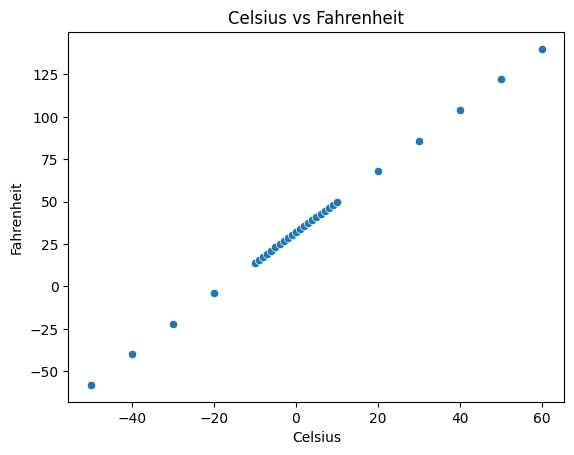

In [7]:
sns.scatterplot(x="Celsius", y="Fahrenheit", data=Temperature_df)
plt.title("Celsius vs Fahrenheit")

# STEP #3: CREATE TESTING AND TRAINING DATASET


In [8]:
# Convert pandas columns to float32 tensors (better path for GPU kernels)
X_train = tf.convert_to_tensor(Temperature_df[["Celsius"]].to_numpy(dtype="float32"))
y_train = tf.convert_to_tensor(Temperature_df[["Fahrenheit"]].to_numpy(dtype="float32"))

print("X_train shape:", X_train.shape, "dtype:", X_train.dtype)
print("y_train shape:", y_train.shape, "dtype:", y_train.dtype)

X_train shape: (30, 1) dtype: <dtype: 'float32'>
y_train shape: (30, 1) dtype: <dtype: 'float32'>


W0000 00:00:1773594812.258978  642864 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
I0000 00:00:1773594812.359453  642864 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13209 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5070 Ti, pci bus id: 0000:01:00.0, compute capability: 12.0a


# STEP#4: BUILD AND TRAIN THE MODEL


In [9]:
model = tf.keras.Sequential(
    [tf.keras.layers.Input(shape=(1,)), tf.keras.layers.Dense(units=5)]
)

In [10]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 5)              │            10 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10 (40.00 B)

 Trainable params: 10 (40.00 B)

 Non-trainable params: 0 (0.00 B)

In [11]:
model.compile(optimizer=tf.keras.optimizers.Adam(0.6), loss="mean_squared_error")

In [12]:
with tf.device('/GPU:0'):
  epochs_history = model.fit(X_train, y_train, epochs=100, verbose=0)
  print("Training complete")
  print("Learned weight:", model.layers[0].get_weights()[0][0][0])
  print("Learned bias:", model.layers[0].get_weights()[1][0])
  print("Initial loss:", float(epochs_history.history["loss"][0]))
  print("Final loss:", float(epochs_history.history["loss"][-1]))

I0000 00:00:1773594813.018152  643034 service.cc:153] XLA service 0x7f970002f630 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1773594813.018182  643034 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 5070 Ti, Compute Capability 12.0a (Driver: 13.2.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.3.0)
I0000 00:00:1773594813.028234  643034 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1773594813.052499  643034 cuda_dnn.cc:461] Loaded cuDNN version 90300
I0000 00:00:1773594813.302731  643034 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


Training complete
Learned weight: 1.8064747
Learned bias: 32.028587
Initial loss: 3035.938720703125
Final loss: 0.02836485020816326


# STEP#5: EVALUATING THE MODEL 

In [13]:
epochs_history.history.keys()

dict_keys(['loss'])

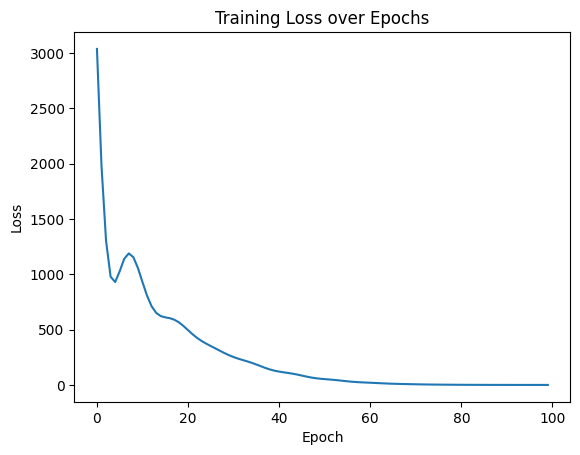

In [14]:
plt.plot(epochs_history.history["loss"])
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss over Epochs")
plt.show()

In [15]:
model.get_weights()

[array([[1.8064747, 1.7937673, 1.7938224, 1.800861 , 1.7892954]],
       dtype=float32),
 array([32.028587, 32.041374, 32.041397, 32.04368 , 32.018047],
       dtype=float32)]

In [16]:
temp_C = [0, 100, 37, -40]
for temp in temp_C:
    temp_tensor = tf.constant([[temp]], dtype=tf.float32)
    temp_F = model.predict(temp_tensor, verbose=0)
    print(f"{temp}°C is approximately {temp_F[0][0]:.2f}°F")

0°C is approximately 32.03°F
100°C is approximately 212.68°F
37°C is approximately 98.87°F
-40°C is approximately -40.23°F
